## Lecture 4 Exercises: GWAS Association

1) Perform Binary Trait Association Testing (30 pts)
a. Provide the command(s) used to run the basic association test for the binary trait.
b. Provide the command(s) used to run the logistic regression analysis adjusted for MDS covariates.
c. Describe any post-processing steps used to clean the logistic regression results before
downstream interpretation.
d. Briefly explain why the covariate-adjusted model may differ from the unadjusted association test.


In [4]:
! cd /Users/kmlanderos/Documents/Johns_Hopkins/Spring_2026/Annotate_a_Genome/data/excercise4

In [1]:
# Basic unadjusted association test
! /Users/kmlanderos/Downloads/plink_mac_20250819/plink \
    --bfile HapMap_3_r3_pop_strat \
    --assoc \
    --out HapMap_basic_assoc
    
# Note, the --assoc option does not allow to correct covariates such as principal components (PC's)/ MDS components, which makes it less suited for association analyses.

PLINK v1.9.0-b.7.11 64-bit (19 Aug 2025)           cog-genomics.org/plink/1.9/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to HapMap_basic_assoc.log.
Options in effect:
  --assoc
  --bfile HapMap_3_r3_pop_strat
  --out HapMap_basic_assoc

18432 MB RAM detected; reserving 9216 MB for main workspace.
1073788 variants loaded from .bim file.
76 people (39 males, 37 females) loaded from .fam.
76 phenotype values loaded from .fam.
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 76 founders and 0 nonfounders present.
Calculating allele frequencies... 10111213141516171819202122232425262728293031323334353637383940414243444546474849505152535455565758596061626364656667686970717273747576777879808182838485868788899091929394959697989 done.
Total genotyping rate is 0.998455.
1073788 variants and 76 people pass filters and QC.
Among remaining phenotypes, 32 are cases and 44 are controls.
Writing C/C --assoc report to HapMa

In [3]:
# Since trait is binary, you must use logistic regression rather than linear regression.

# Logistic regression adjusted for the 10 MDS covariates
! /Users/kmlanderos/Downloads/plink_mac_20250819/plink \
    --bfile HapMap_3_r3_pop_strat \
    --covar covar_mds.txt \
    --logistic \
    --hide-covar \
    --out HapMap_logistic_assoc

# Option --hide-covar to only show the additive results of the SNPs in the output file.   

# Remove NA values, those might give problems generating plots in later steps.
# Clean the logistic regression output: Keep header (NR==1) or 'ADD' test rows, and drop 'NA's
! awk '!/NA/ && ($5=="ADD" || NR==1)' HapMap_logistic_assoc.assoc.logistic > HapMap_logistic_assoc_clean.assoc.logistic
# ! awk '!/'NA'/' HapMap_logistic_assoc.assoc.logistic > HapMap_logistic_assoc.assoc_2.logistic 

PLINK v1.9.0-b.7.11 64-bit (19 Aug 2025)           cog-genomics.org/plink/1.9/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to HapMap_logistic_assoc.log.
Options in effect:
  --bfile HapMap_3_r3_pop_strat
  --covar covar_mds.txt
  --hide-covar
  --logistic
  --out HapMap_logistic_assoc

Note: --hide-covar flag deprecated.  Use e.g. "--linear hide-covar".
18432 MB RAM detected; reserving 9216 MB for main workspace.
1073788 variants loaded from .bim file.
76 people (39 males, 37 females) loaded from .fam.
76 phenotype values loaded from .fam.
Using 1 thread (no multithreaded calculations invoked).
--covar: 10 covariates loaded.
Before main variant filters, 76 founders and 0 nonfounders present.
Calculating allele frequencies... 10111213141516171819202122232425262728293031323334353637383940414243444546474849505152535455565758596061626364656667686970717273747576777879808182838485868788899091929394959697989 done.
Total genotyping rate is 0.998455.
1

2) Evaluate Multiple Testing Correction in GWAS (30 pts)
a. Provide the command(s) used to obtain multiple-testing adjusted association results for the full dataset.
b. Provide the command(s) used to run the permutation-based association testing.
Note: Because permutation testing is computationally intensive, this analysis can be performed on a smaller subset of SNPs rather than the full dataset. Indicate how SNPs were subset for this analysis.

In [4]:
# Multiple testing

# Run logistic regression with the --adjust flag to generate corrected p-values
! /Users/kmlanderos/Downloads/plink_mac_20250819/plink \
    --bfile HapMap_3_r3_pop_strat \
    --covar covar_mds.txt \
    --logistic \
    --hide-covar \
    --adjust \
    --out HapMap_logistic_adjusted

# ! /Users/kmlanderos/Downloads/plink_mac_20250819/plink --bfile HapMap_3_r3_pop_strat -assoc --adjust --out adjusted_assoc_results
# This file gives a Bonferroni corrected p-value, along with FDR and others.

PLINK v1.9.0-b.7.11 64-bit (19 Aug 2025)           cog-genomics.org/plink/1.9/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to HapMap_logistic_adjusted.log.
Options in effect:
  --adjust
  --bfile HapMap_3_r3_pop_strat
  --covar covar_mds.txt
  --hide-covar
  --logistic
  --out HapMap_logistic_adjusted

Note: --hide-covar flag deprecated.  Use e.g. "--linear hide-covar".
18432 MB RAM detected; reserving 9216 MB for main workspace.
1073788 variants loaded from .bim file.
76 people (39 males, 37 females) loaded from .fam.
76 phenotype values loaded from .fam.
Using 1 thread (no multithreaded calculations invoked).
--covar: 10 covariates loaded.
Before main variant filters, 76 founders and 0 nonfounders present.
Calculating allele frequencies... 10111213141516171819202122232425262728293031323334353637383940414243444546474849505152535455565758596061626364656667686970717273747576777879808182838485868788899091929394959697989 done.
Total genotyping ra

In [1]:
# Permutation-based association testing

# 1. Subset the SNPs to Chromosome 22 only
! awk '{ if ($4 >= 21595000 && $4 <= 21605000) print $2 }' HapMap_3_r3_pop_strat.bim > subset_snp_chr_22.txt
# Filter your bfile based on the subset of SNPs generated in the step above.
! /Users/kmlanderos/Downloads/plink_mac_20250819/plink --bfile HapMap_3_r3_pop_strat --extract subset_snp_chr_22.txt --make-bed --out HapMap_subset_for_perm

# 2. Run permutation testing (1000 permutations) on the Chromosome 22 subset
! /Users/kmlanderos/Downloads/plink_mac_20250819/plink \
    --bfile HapMap_subset_for_perm \
    --covar covar_mds.txt \
    --logistic \
    --hide-covar \
    --mperm 1000 \
    --out HapMap_perm_chr22

PLINK v1.9.0-b.7.11 64-bit (19 Aug 2025)           cog-genomics.org/plink/1.9/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to HapMap_subset_for_perm.log.
Options in effect:
  --bfile HapMap_3_r3_pop_strat
  --extract subset_snp_chr_22.txt
  --make-bed
  --out HapMap_subset_for_perm

18432 MB RAM detected; reserving 9216 MB for main workspace.
1073788 variants loaded from .bim file.
76 people (39 males, 37 females) loaded from .fam.
76 phenotype values loaded from .fam.
--extract: 84 variants remaining.
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 76 founders and 0 nonfounders present.
Calculating allele frequencies... 10111213141516171819202122232425262728293031323334353637383940414243444546474849505152535455565758596061626364656667686970717273747576777879808182838485868788899091929394959697989 done.
Total genotyping rate is 0.997807.
84 variants and 76 people pass filters and QC.
Among remaining phenoty

3) Visualize GWAS Results(40 pts)
a. Generate Manhattan plots using the association results (include code +plots)
b. Generate QQ plots using the association results (include code +plots)

Generating Logistic Manhattan Plot...


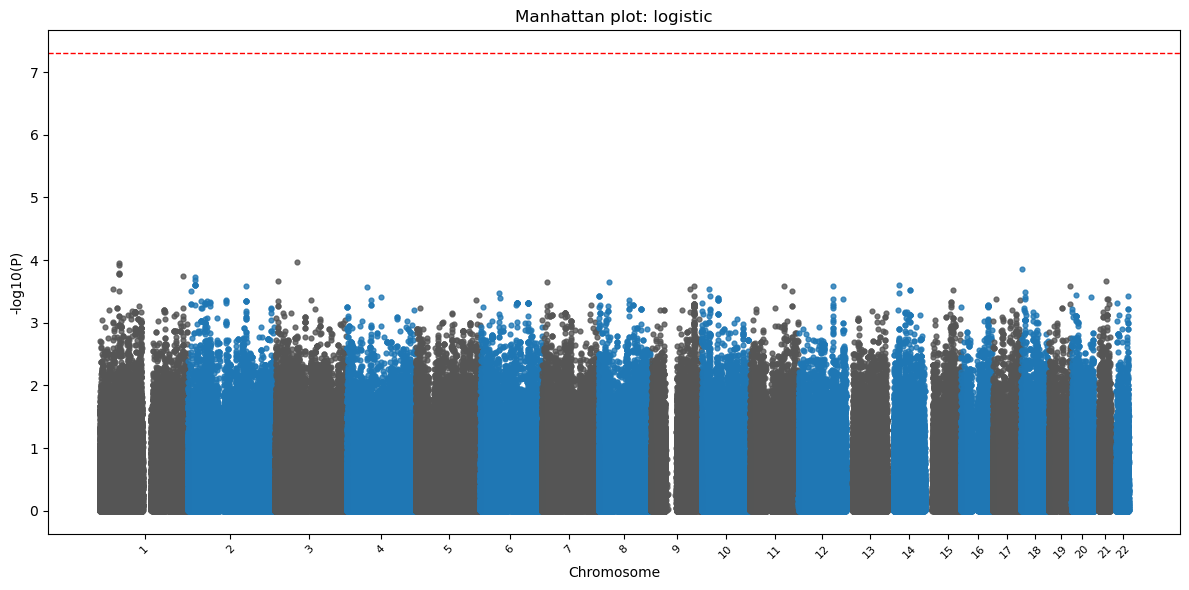

Generating Basic Assoc Manhattan Plot...


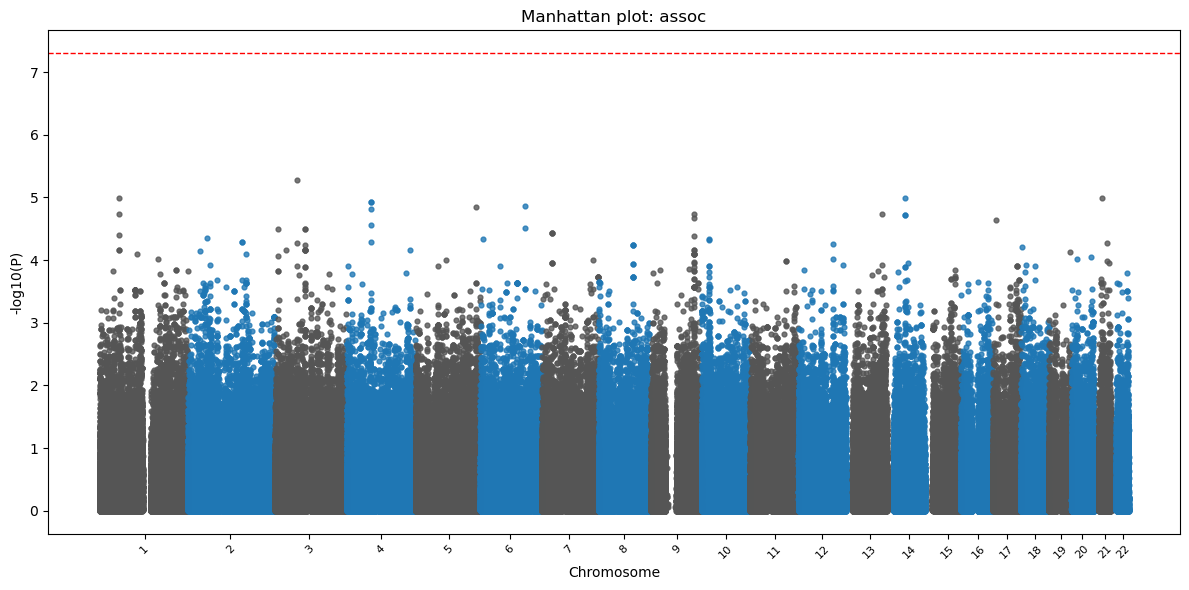

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def make_manhattan_plot(df, title, filename):
    """
    Replicates the R qqman::manhattan() function.
    """
    # 1. Clean the data (remove NAs and P-values of 0 to prevent log errors)
    # For logistic regression, we only want the additive genetic model ('ADD')
    if 'TEST' in df.columns:
        df = df[df['TEST'] == 'ADD']
        
    df = df.dropna(subset=['P', 'CHR', 'BP'])
    df = df[df['P'] > 0]
    
    # Ensure CHR is numeric (drops X, Y, MT if they aren't mapped to numbers)
    df['CHR'] = pd.to_numeric(df['CHR'], errors='coerce')
    df = df.dropna(subset=['CHR'])
    
    # Calculate -log10(P)
    df['-log10(P)'] = -np.log10(df['P'])
    
    # Sort by chromosome and position
    df = df.sort_values(['CHR', 'BP'])
    
    # 2. Calculate cumulative base pair positions for the x-axis
    df['BP_cum'] = 0
    running_pos = 0
    x_labels = []
    x_labels_pos = []
    
    for chr_num, group in df.groupby('CHR'):
        # Shift the BP coordinates by the running total
        cumulative_bp = group['BP'] + running_pos
        df.loc[group.index, 'BP_cum'] = cumulative_bp
        
        # Calculate where to place the x-axis tick (center of the chromosome)
        x_labels.append(str(int(chr_num)))
        x_labels_pos.append(cumulative_bp.mean())
        
        # Update running position for the next chromosome
        running_pos += group['BP'].max()

    # 3. Plotting
    plt.figure(figsize=(12, 6))
    colors = ['#555555', '#1f77b4'] 
    
    for num, (chr_num, group) in enumerate(df.groupby('CHR')):
        plt.scatter(group['BP_cum'], group['-log10(P)'], 
                    color=colors[num % len(colors)], s=12, alpha=0.8)
    
    # Formatting
    plt.axhline(y=-np.log10(5e-8), color='red', linestyle='--', linewidth=1) # Genome-wide significance line
    plt.xticks(x_labels_pos, x_labels, fontsize=8, rotation=45)
    plt.xlabel('Chromosome')
    plt.ylabel('-log10(P)')
    plt.title(title)
    
    # Save and show
    plt.tight_layout()
    plt.savefig(filename, format='jpeg', dpi=300)
    plt.show()

# --- Execution ---

# 1. Logistic Regression Manhattan Plot
print("Generating Logistic Manhattan Plot...")
results_log = pd.read_csv("HapMap_logistic_assoc.assoc.logistic", sep=r'\s+')
make_manhattan_plot(results_log, "Manhattan plot: logistic", "Logistic_manhattan.jpeg")

# 2. Basic Association Manhattan Plot
print("Generating Basic Assoc Manhattan Plot...")
results_as = pd.read_csv("HapMap_basic_assoc.assoc", sep=r'\s+')
make_manhattan_plot(results_as, "Manhattan plot: assoc", "assoc_manhattan.jpeg")

Generating Logistic Q-Q Plot...


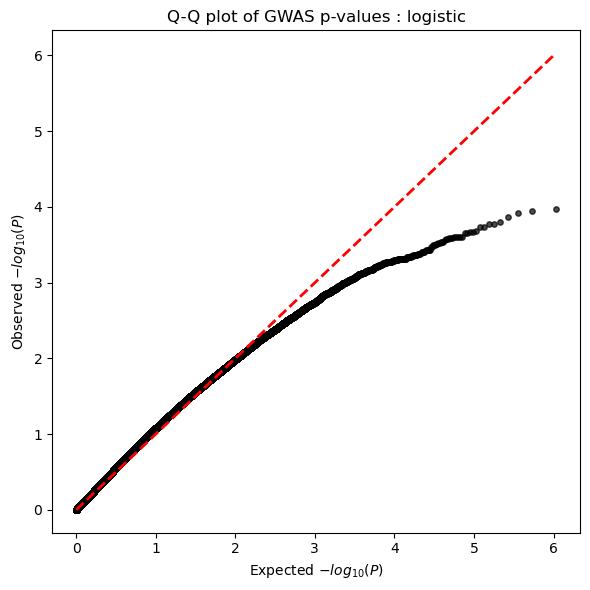

Generating Basic Assoc Q-Q Plot...


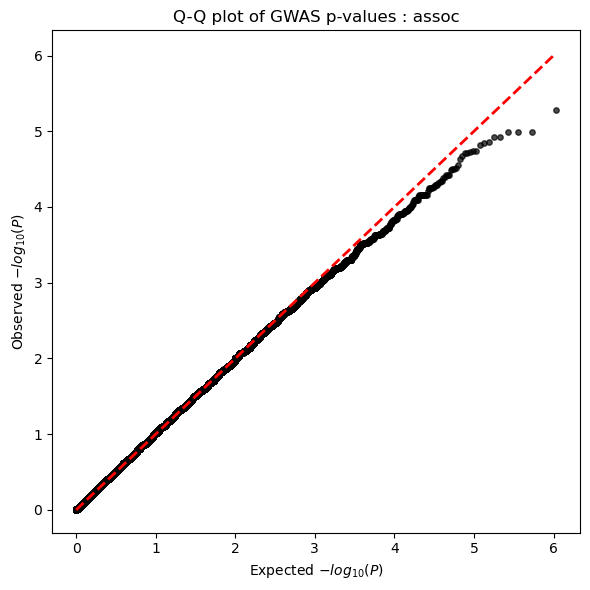

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def make_qq_plot(df, title, filename):
    """
    Replicates the R qqman::qq() function for GWAS p-values.
    """
    # 1. Clean the data
    # For logistic regression, only plot the main additive SNP effect
    if 'TEST' in df.columns:
        df = df[df['TEST'] == 'ADD']
        
    # Drop missing or invalid p-values
    p_vals = df['P'].dropna()
    p_vals = p_vals[(p_vals > 0) & (p_vals <= 1)]
    
    # 2. Sort observed p-values and calculate -log10
    observed = -np.log10(np.sort(p_vals))
    
    # 3. Generate expected uniform p-values and calculate -log10
    n = len(p_vals)
    expected = -np.log10(np.arange(1, n + 1) / (n + 1))
    
    # 4. Plotting
    plt.figure(figsize=(6, 6))
    plt.scatter(expected, observed, color='black', s=15, alpha=0.7)
    
    # Add the y=x reference line (red dashed line)
    max_val = max(np.max(expected), np.max(observed))
    plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', linewidth=2)
    
    # Formatting
    plt.title(title)
    plt.xlabel('Expected $-log_{10}(P)$')
    plt.ylabel('Observed $-log_{10}(P)$')
    
    # Save and show
    plt.tight_layout()
    plt.savefig(filename, format='jpeg', dpi=300)
    plt.show()

# --- Execution ---

# 1. Logistic Regression Q-Q Plot
print("Generating Logistic Q-Q Plot...")
results_log = pd.read_csv("HapMap_logistic_assoc.assoc.logistic", sep=r'\s+')
make_qq_plot(results_log, "Q-Q plot of GWAS p-values : logistic", "QQ-Plot_logistic.jpeg")

# 2. Basic Association Q-Q Plot
print("Generating Basic Assoc Q-Q Plot...")
results_as = pd.read_csv("HapMap_basic_assoc.assoc", sep=r'\s+')
make_qq_plot(results_as, "Q-Q plot of GWAS p-values : assoc", "QQ-Plot_assoc.jpeg")